In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PassiveAggressiveRegressor

data = pd.read_csv("Instagram data.csv",encoding='latin1')
data.head()

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags
0,3920,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...
1,5394,2727,1838,1174,78,194,7,14,224,48,10,Here are some of the best data science project...,#healthcare #health #covid #data #datascience ...
2,4021,2085,1188,0,533,41,11,1,131,62,12,Learn how to train a machine learning model an...,#data #datascience #dataanalysis #dataanalytic...
3,4528,2700,621,932,73,172,10,7,213,23,8,Heres how you can write a Python program to d...,#python #pythonprogramming #pythonprojects #py...
4,2518,1704,255,279,37,96,5,4,123,8,0,Plotting annotations while visualizing your da...,#datavisualization #datascience #data #dataana...


In [53]:
data.isnull().sum()

Impressions       0
From Home         0
From Hashtags     0
From Explore      0
From Other        0
Saves             0
Comments          0
Shares            0
Likes             0
Profile Visits    0
Follows           0
Caption           0
Hashtags          0
dtype: int64

In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Impressions     119 non-null    int64 
 1   From Home       119 non-null    int64 
 2   From Hashtags   119 non-null    int64 
 3   From Explore    119 non-null    int64 
 4   From Other      119 non-null    int64 
 5   Saves           119 non-null    int64 
 6   Comments        119 non-null    int64 
 7   Shares          119 non-null    int64 
 8   Likes           119 non-null    int64 
 9   Profile Visits  119 non-null    int64 
 10  Follows         119 non-null    int64 
 11  Caption         119 non-null    object
 12  Hashtags        119 non-null    object
dtypes: int64(11), object(2)
memory usage: 12.2+ KB


# Analyzing Instagram Reach

C:\Users\Shivam Bhusari\AppData\Local\Temp\ipykernel_12496\1467852502.py:4: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




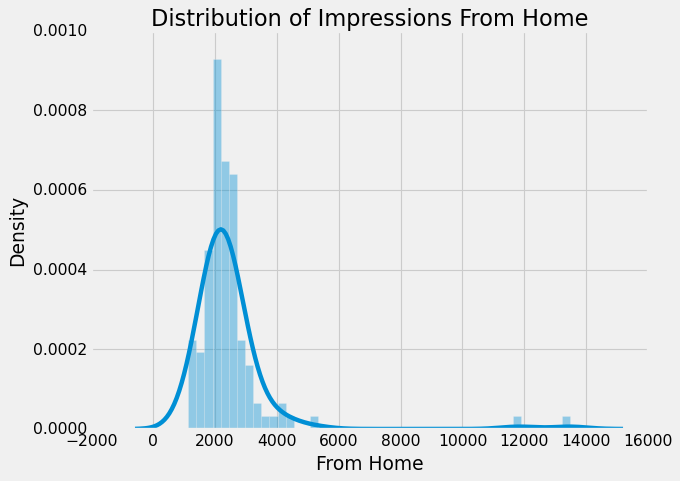

In [55]:
plt.Figure(figsize=(10,8))
plt.style.use('fivethirtyeight')
plt.title("Distribution of Impressions From Home")
sns.distplot(data['From Home'])
plt.show()

C:\Users\Shivam Bhusari\AppData\Local\Temp\ipykernel_12496\3294356597.py:3: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




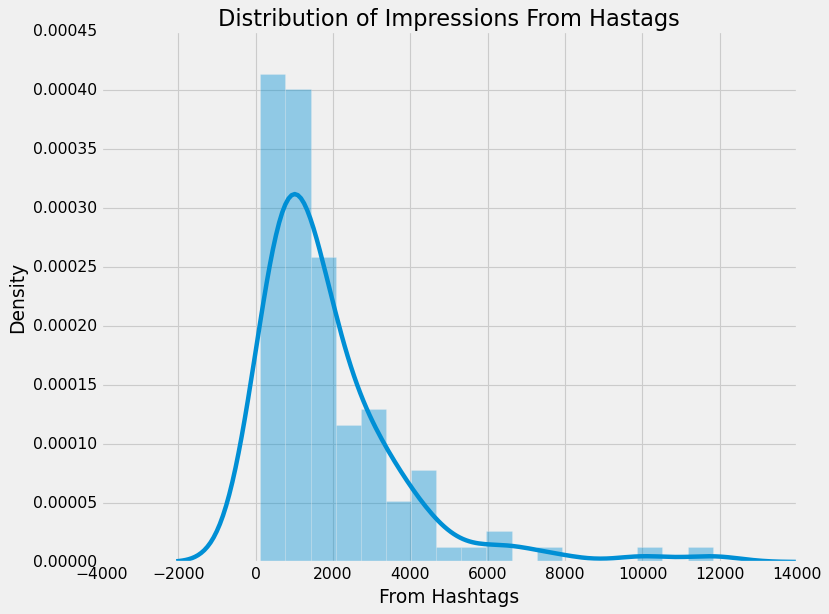

In [56]:
plt.figure(figsize=(10,8))
plt.title("Distribution of Impressions From Hastags")
sns.distplot(data['From Hashtags'])
plt.show()

C:\Users\Shivam Bhusari\AppData\Local\Temp\ipykernel_12496\2005697785.py:3: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




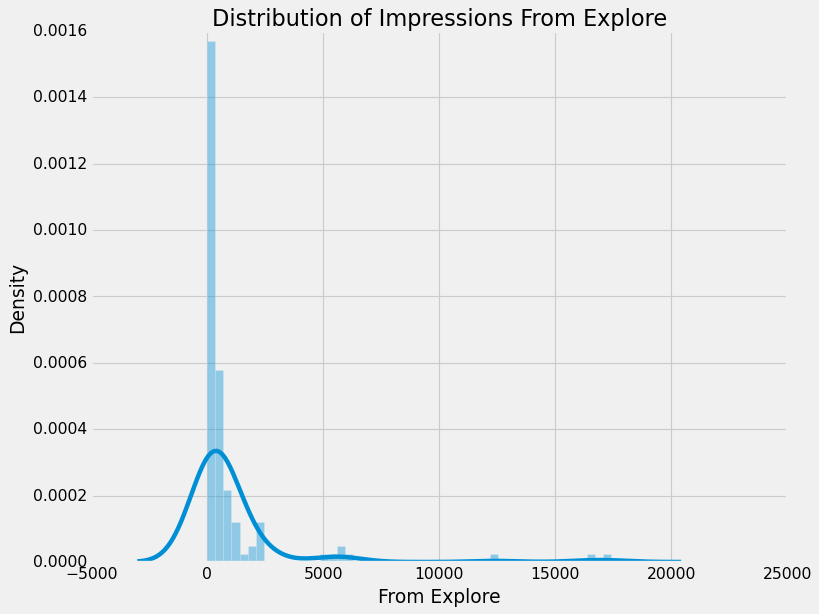

In [57]:
plt.figure(figsize=(10,8))
plt.title("Distribution of Impressions From Explore")
sns.distplot(data['From Explore'])
plt.show()

In [58]:
home = data['From Home'].sum()
hashtags = data['From Hashtags'].sum()
explore = data["From Explore"].sum()
other = data["From Other"].sum()

labels = ['From Home','From Hashtags','From Explore','Other']
values = [home,hashtags,explore,other]

fig = px.pie(data,values=values,names=labels,title='Impressions on Instagram Posts From Various Sources',hole=0.5)
fig.show()

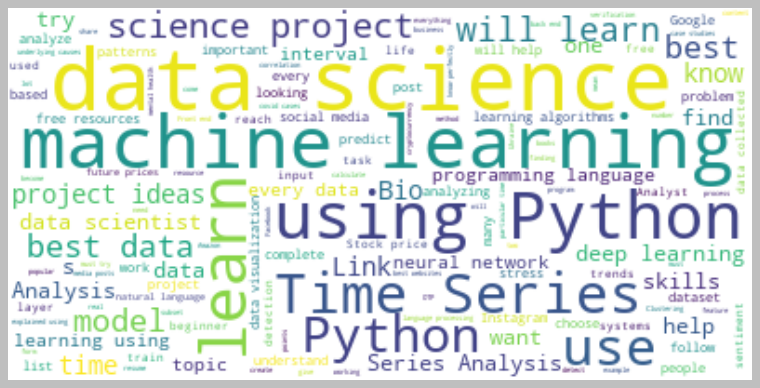

In [59]:
text = " ".join(i for i in data.Caption)
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords,background_color='white').generate(text)
plt.style.use('classic')
plt.figure(figsize=(12,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

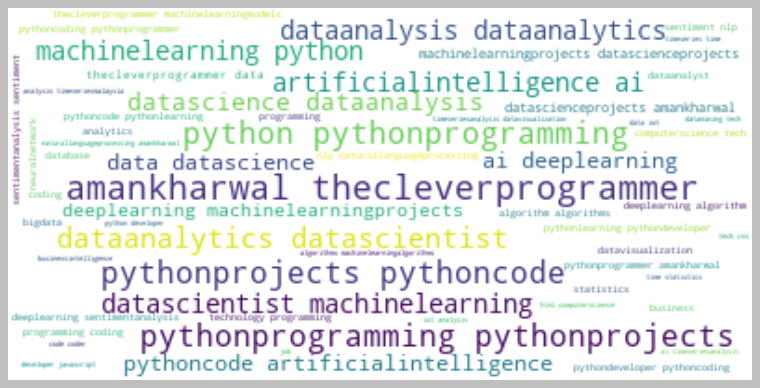

In [60]:
text = " ".join(i for i in data.Hashtags)
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords,background_color='white').generate(text)
plt.style.use('classic')
plt.figure(figsize=(12,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# Analyzing Relationships

In [61]:
figure = px.scatter(data_frame=data,x='Impressions',
                    y='Likes',size='Likes',trendline='ols',
                    title="Relationship Between Likes and Impressions")
figure.show()

In [62]:
figure = px.scatter(data_frame=data,x='Impressions',
                    y='Comments',size='Comments',trendline='ols',
                    title="Relationship Between Comments and Impressions")
figure.show()

In [63]:
figure = px.scatter(data_frame=data,x='Impressions',
                    y='Shares',size='Shares',trendline='ols',
                    title="Relationship Between Shares and Impressions")
figure.show()

In [64]:
figure = px.scatter(data_frame=data,x='Impressions',
                    y='Saves',size='Saves',trendline='ols',
                    title="Relationship Between Saves and Impressions")
figure.show()

# Analyzing Conversion Rate

In [65]:
coversion_rate = (data['Follows'].sum()/data['Profile Visits'].sum())*100
print(coversion_rate)

41.00265604249668


In [66]:
figure = px.scatter(data_frame=data,x='Profile Visits',
                    y = 'Follows',size = 'Follows',trendline='ols',
                    title='Relationship Between Profile Visits and Followers Gained')
figure.show()

# Instagram Reach Prediction Model


In [67]:
x = np.array(data[['Likes','Saves','Comments','Shares','Profile Visits','Follows']])
y = np.array(data['Impressions'])
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=0.2,random_state=42)

In [68]:
model = PassiveAggressiveRegressor()
model.fit(xtrain,ytrain)


,C,1.0
,fit_intercept,True
,max_iter,1000
,tol,0.001
,early_stopping,False
,validation_fraction,0.1
,n_iter_no_change,5
,shuffle,True
,verbose,0
,loss,'epsilon_insensitive'
,epsilon,0.1


In [69]:
model.score(xtest,ytest)

0.8646921199827136

In [70]:
features = np.array([[282.0,233.0,4.0,9.0,165.0,54.0]])
model.predict(features)

array([13587.46634244])